# Supplementary Figure S1: `s01_calibration_mosaic`

**Calibration image set.** The full mosaic of the $969$ natural and synthetic images used to fit the encoding models is shown, grouped by the source of the images. Within each source, images are sorted by mean IT response (high to low), with borders coding the corresponding firing rates averaged across the five aIT electrodes from Monkey R (blue $=$ low, white $=$ median, red $=$ high spk/s). The three sources are NSD natural scenes ($n = 649$), segmented objects and animals on white backgrounds ($n = 259$), and fLoc functional-localizer images ($n = 61$). The strongest responses were driven by images of human faces (see the warm-bordered thumbnails in the segmented-object and fLoc blocks).

Rendered by `figures/supplementary/sup_calibration_mosaic.py`; the PNG written below is pixel-identical to the manuscript file `s01_calibration_mosaic.png` in the reference environment (see docs/REPRODUCIBILITY.md). The preview shown here is downscaled.

In [1]:
import os, sys
from pathlib import Path

# Keep BLAS single-threaded: multithreaded OpenMP together with torch can kill the kernel on macOS.
for _v in ('OMP_NUM_THREADS', 'OPENBLAS_NUM_THREADS', 'MKL_NUM_THREADS', 'VECLIB_MAXIMUM_THREADS'):
    os.environ.setdefault(_v, '1')
os.environ.setdefault('KMP_DUPLICATE_LIB_OK', 'TRUE')

# Render with the Agg backend and matplotlib's defaults, exactly like the figure scripts;
# Jupyter's inline backend would otherwise change dpi and bounding boxes.
os.environ['MPLBACKEND'] = 'Agg'
import matplotlib; matplotlib.use('Agg'); matplotlib.rcdefaults()

# Work from the repository root whether the notebook is opened there or in notebooks/figures/.
REPO = Path.cwd() if (Path.cwd() / 'pnc').exists() else Path.cwd().parents[1]
sys.path.insert(0, str(REPO))
from pnc import paths

# The figures read the preprocessed caches only; this raises a clear message if they are missing.
paths.require(paths.preprocessed_data() / 'brain_red.pkl')   # python data/download_data.py --tier preprocessed
out_dir = paths.output_dir() / 'figures'
out_dir.mkdir(parents=True, exist_ok=True)

In [2]:
from figures.supplementary.sup_calibration_mosaic import main

# main() writes <out_dir>/<manuscript name>.png (border-trimmed, so it matches the submitted file)
# and returns its path; keyword arguments select the non-default variants documented in the script.
png = main(str(out_dir))
print(png)

NSD 649 + segmented 259 + fLoc 61 = 969
Saved -> /private/tmp/claude-501/-Users-jacobprince-KonkLab-Dropbox-Jacob-Prince-Research-Prince-Accentuate-VVS-Manuscript/bca6882d-ec2d-4dbd-beb1-0d67d8b1fcc7/scratchpad/nb_exec_out/figures/s01_calibration_mosaic.png
/private/tmp/claude-501/-Users-jacobprince-KonkLab-Dropbox-Jacob-Prince-Research-Prince-Accentuate-VVS-Manuscript/bca6882d-ec2d-4dbd-beb1-0d67d8b1fcc7/scratchpad/nb_exec_out/figures/s01_calibration_mosaic.png


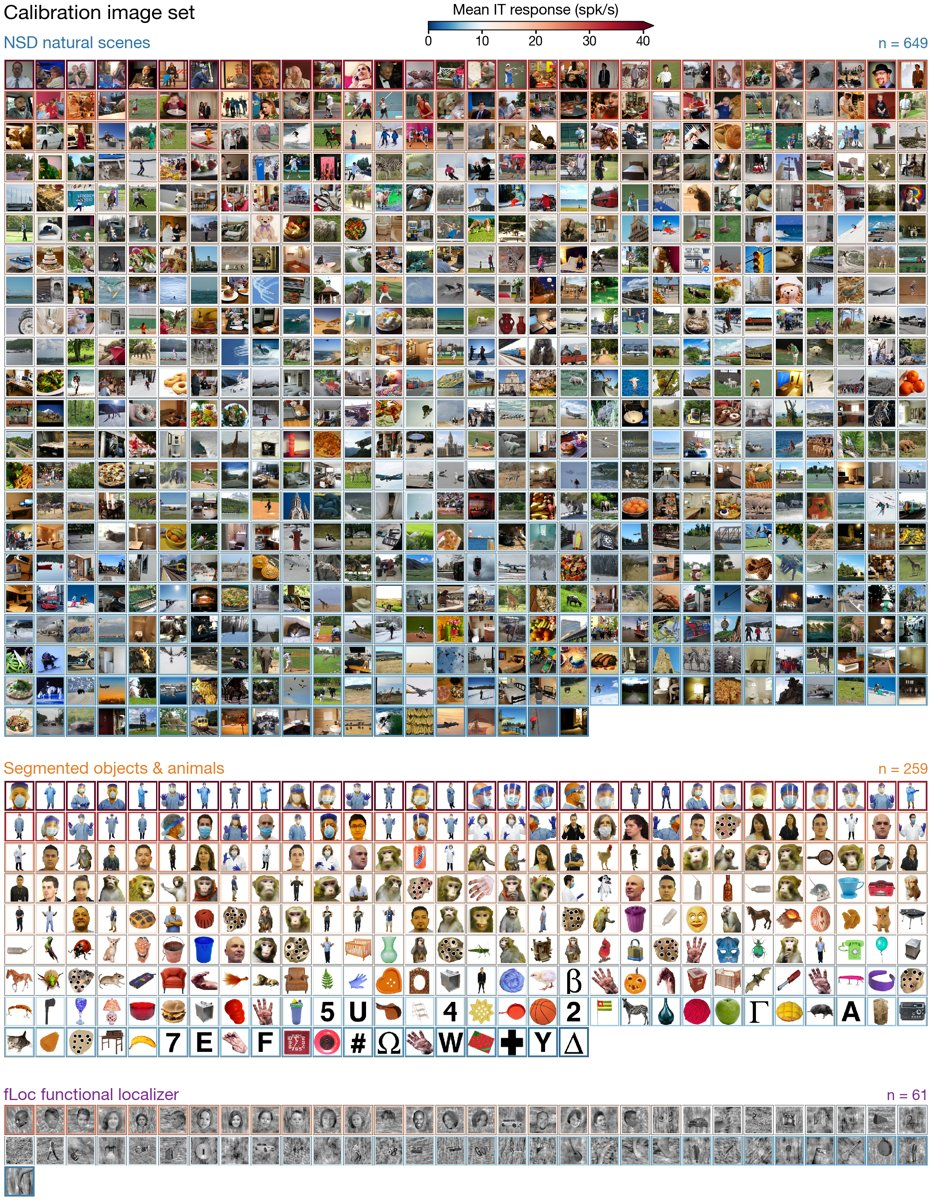

In [3]:
import io
from IPython.display import Image, display
from PIL import Image as PILImage

# Show a downscaled JPEG preview (the full-resolution PNG can be tens of MB); open the file for detail.
im = PILImage.open(png).convert("RGB")
im.thumbnail((1200, 1200))
buf = io.BytesIO(); im.save(buf, "JPEG", quality=85, optimize=True)
display(Image(data=buf.getvalue(), format="jpeg", width=900))